# 1: Imports & Root Detection

In [ ]:
# import the imports.
import sys, time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from sklearn.metrics import (confusion_matrix, f1_score, precision_score, recall_score)


root = Path.cwd()
while not (root / "Pipeline_").exists() and root != root.parent:
    root = root.parent

if str(root) not in sys.path:
    sys.path.insert(0, str(root))

print("Project root:", root)


# load preprocessor and model definition.
from Pipeline_.preprocessor import WaRPPreprocessor
from Models.ResNet50 import ResNet50


# GPU is used if available
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

Project root: c:\repo\Waste-Classification
Device: cuda


# 2: Hyperparameters

In [ ]:
EPOCHS          = 40         
BATCH_SIZE      = 32         
LR              = 1e-4      
WEIGHT_DECAY    = 1e-4       
DROPOUT         = 0.4        
NUM_CLASSES     = 28         
NUM_WORKERS     = 4          

print("Epochs      :", EPOCHS)
print("Batch size  :", BATCH_SIZE)
print("LR          :", LR)
print("Dropout     :", DROPOUT)
print("Num classes :", NUM_CLASSES)
print("Num workers :", NUM_WORKERS)

Epochs      : 40
Batch size  : 32
LR          : 0.0001
Dropout     : 0.4
Num classes : 28
Num workers : 4


# 3: Data Pipeline

In [ ]:
# init pre-processor 
pp = WaRPPreprocessor(
    raw_root       = root / "Dataset/raw/Warp-C",          
    processed_root = root / "Dataset/processed",          
    stats_file     = root / "Dataset/dataset_stats.json",  
    batch_size     = BATCH_SIZE,                           
    num_workers    = NUM_WORKERS                            
)


train_loader, test_loader = pp.get_loaders(model_type="resnet50")

CLASS_NAMES = sorted(d.name for d in (root / "Dataset/processed/train").iterdir() if d.is_dir())

print(f"Classes       : {len(CLASS_NAMES)}")
print(f"Train batches : {len(train_loader)}")
print(f"Test  batches : {len(test_loader)}")

[get_loaders] model='resnet50'
  sampler=True  minority_aug=True  mixup=False  pipeline='pretrained_cnn'
  train=273 batches  test=49 batches  sampler=WeightedRandom
Classes       : 28
Train batches : 273
Test  batches : 49


# 4: Loss, Model, Optimizer

In [ ]:
# weighted cross-entropy 
class_weights = pp.get_class_weights(device=DEVICE)

# cross-entropy loss 
criterion = nn.CrossEntropyLoss(weight=class_weights)
print("Loss: CrossEntropyLoss + class weights")

# Instantiate ResNet50 as defined in the ResNet50.py file.
# freeze == false ensure backbone layers are trainable for a full fine-tuning setup.
model = ResNet50(num_classes = NUM_CLASSES, dropout = DROPOUT, freeze = False).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr = LR, weight_decay = WEIGHT_DECAY)

with torch.no_grad():                           
    x = torch.zeros(2, 3, 224, 224).to(DEVICE)  
    y = model(x)                                
print("Sanity output:", y.shape)                

Loss: CrossEntropyLoss + class weights
Sanity output: torch.Size([2, 28])


# 5: Training Loop

In [ ]:

# save training loss & accuracy, and test accuracy.
train_losses, train_accs, test_accs = [], [], []

# Hold best current accuracy 
best_acc = 0.0

# Path to save the best model checkpoint
WEIGHTS_PATH = root / "Models/weights/resnet50_baseline_224.pth"

print(f"Starting {EPOCHS} epochs...\n")

# main training loop.
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    model.train() #set training mode (use dropout, batch norm, layer norm)
    ep_loss = correct = total = 0 # reset batch metrics

    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)

        optimizer.zero_grad()              
        logits = model(imgs)                
        loss   = criterion(logits, lbls)  
        loss.backward()                    
        optimizer.step()                   

        # batch metrics (accumulated) 
        ep_loss += loss.item()
        correct += (logits.argmax(1) == lbls).sum().item()
        total   += lbls.size(0)

    # Computer accuracy and loss 
    train_loss = ep_loss / len(train_loader)
    train_acc  = correct / total * 100

    # Evaluation here 
    model.eval()                                           
    correct = total = 0                                     
    with torch.no_grad():                                   
        for imgs, lbls in test_loader:                      
            preds = model(imgs.to(DEVICE)).argmax(1).cpu() 
            correct += (preds == lbls).sum().item()          
            total   += lbls.size(0)                      
    test_acc = correct / total * 100                        

    # save metrics, used for plotting
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    # save best model 
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), WEIGHTS_PATH)
        flag = " ← best"
    else:
        flag = ""

    print(f"Epoch {epoch:3d}/{EPOCHS} | "
          f"loss={train_loss:.4f} | train={train_acc:.2f}% | "
          f"test={test_acc:.2f}% | best={best_acc:.2f}% | "
          f"{time.time()-t0:.1f}s{flag}")


Starting 40 epochs...

Epoch   1/40 | loss=2.1190 | train=18.98% | test=21.92% | best=21.92% | 30.7s ← best
Epoch   2/40 | loss=0.9727 | train=51.30% | test=49.07% | best=49.07% | 17.0s ← best
Epoch   3/40 | loss=0.6982 | train=62.21% | test=54.16% | best=54.16% | 17.0s ← best
Epoch   4/40 | loss=0.5713 | train=68.36% | test=56.42% | best=56.42% | 17.1s ← best
Epoch   5/40 | loss=0.4781 | train=72.71% | test=59.64% | best=59.64% | 17.1s ← best
Epoch   6/40 | loss=0.4533 | train=73.74% | test=61.38% | best=61.38% | 17.0s ← best
Epoch   7/40 | loss=0.3492 | train=78.23% | test=60.35% | best=61.38% | 17.0s
Epoch   8/40 | loss=0.3204 | train=79.89% | test=64.54% | best=64.54% | 17.0s ← best
Epoch   9/40 | loss=0.2989 | train=81.12% | test=64.22% | best=64.54% | 16.9s
Epoch  10/40 | loss=0.2677 | train=81.77% | test=65.51% | best=65.51% | 17.0s ← best
Epoch  11/40 | loss=0.2775 | train=82.14% | test=63.64% | best=65.51% | 17.0s
Epoch  12/40 | loss=0.2550 | train=83.67% | test=66.02% | best=

# 6: Training Curves

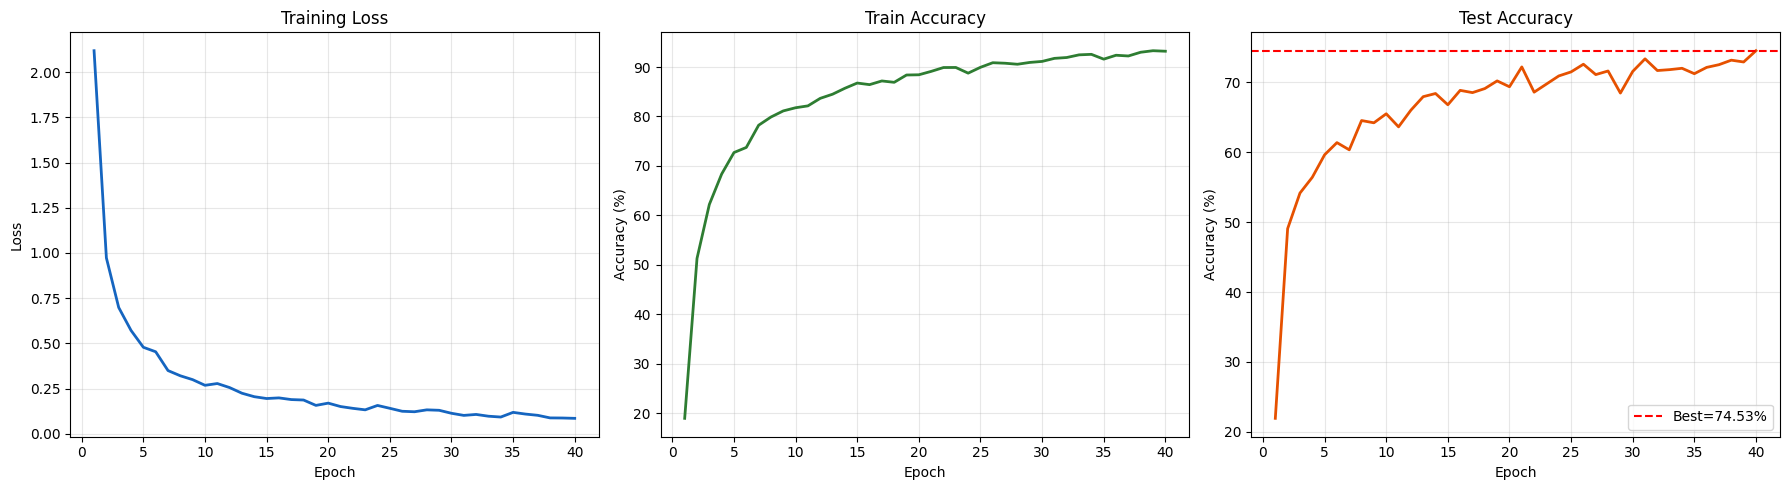

In [ ]:
# Plot training curves: loss, train accuracy, test accuracy
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ep = range(1, EPOCHS + 1)

axes[0].plot(ep, train_losses, "#1565C0", lw=2)
axes[0].set(title="Training Loss", xlabel="Epoch", ylabel="Loss")
axes[0].grid(alpha=0.3)

axes[1].plot(ep, train_accs, "#2E7D32", lw=2)
axes[1].set(title="Train Accuracy", xlabel="Epoch", ylabel="Accuracy (%)")
axes[1].grid(alpha=0.3)

axes[2].plot(ep, test_accs, "#E65100", lw=2)
axes[2].axhline(max(test_accs), color="red", ls="--", label=f"Best={max(test_accs):.2f}%")
axes[2].set(title="Test Accuracy", xlabel="Epoch", ylabel="Accuracy (%)")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 7: Final Evaluation & Confusion Matrix

ResNet50 Baseline (224px): Final Metrics
Accuracy     : 74.53%
Macro F1     : 74.06%
Weighted F1  : 74.14%
Precision    : 75.83%
Recall       : 75.43%


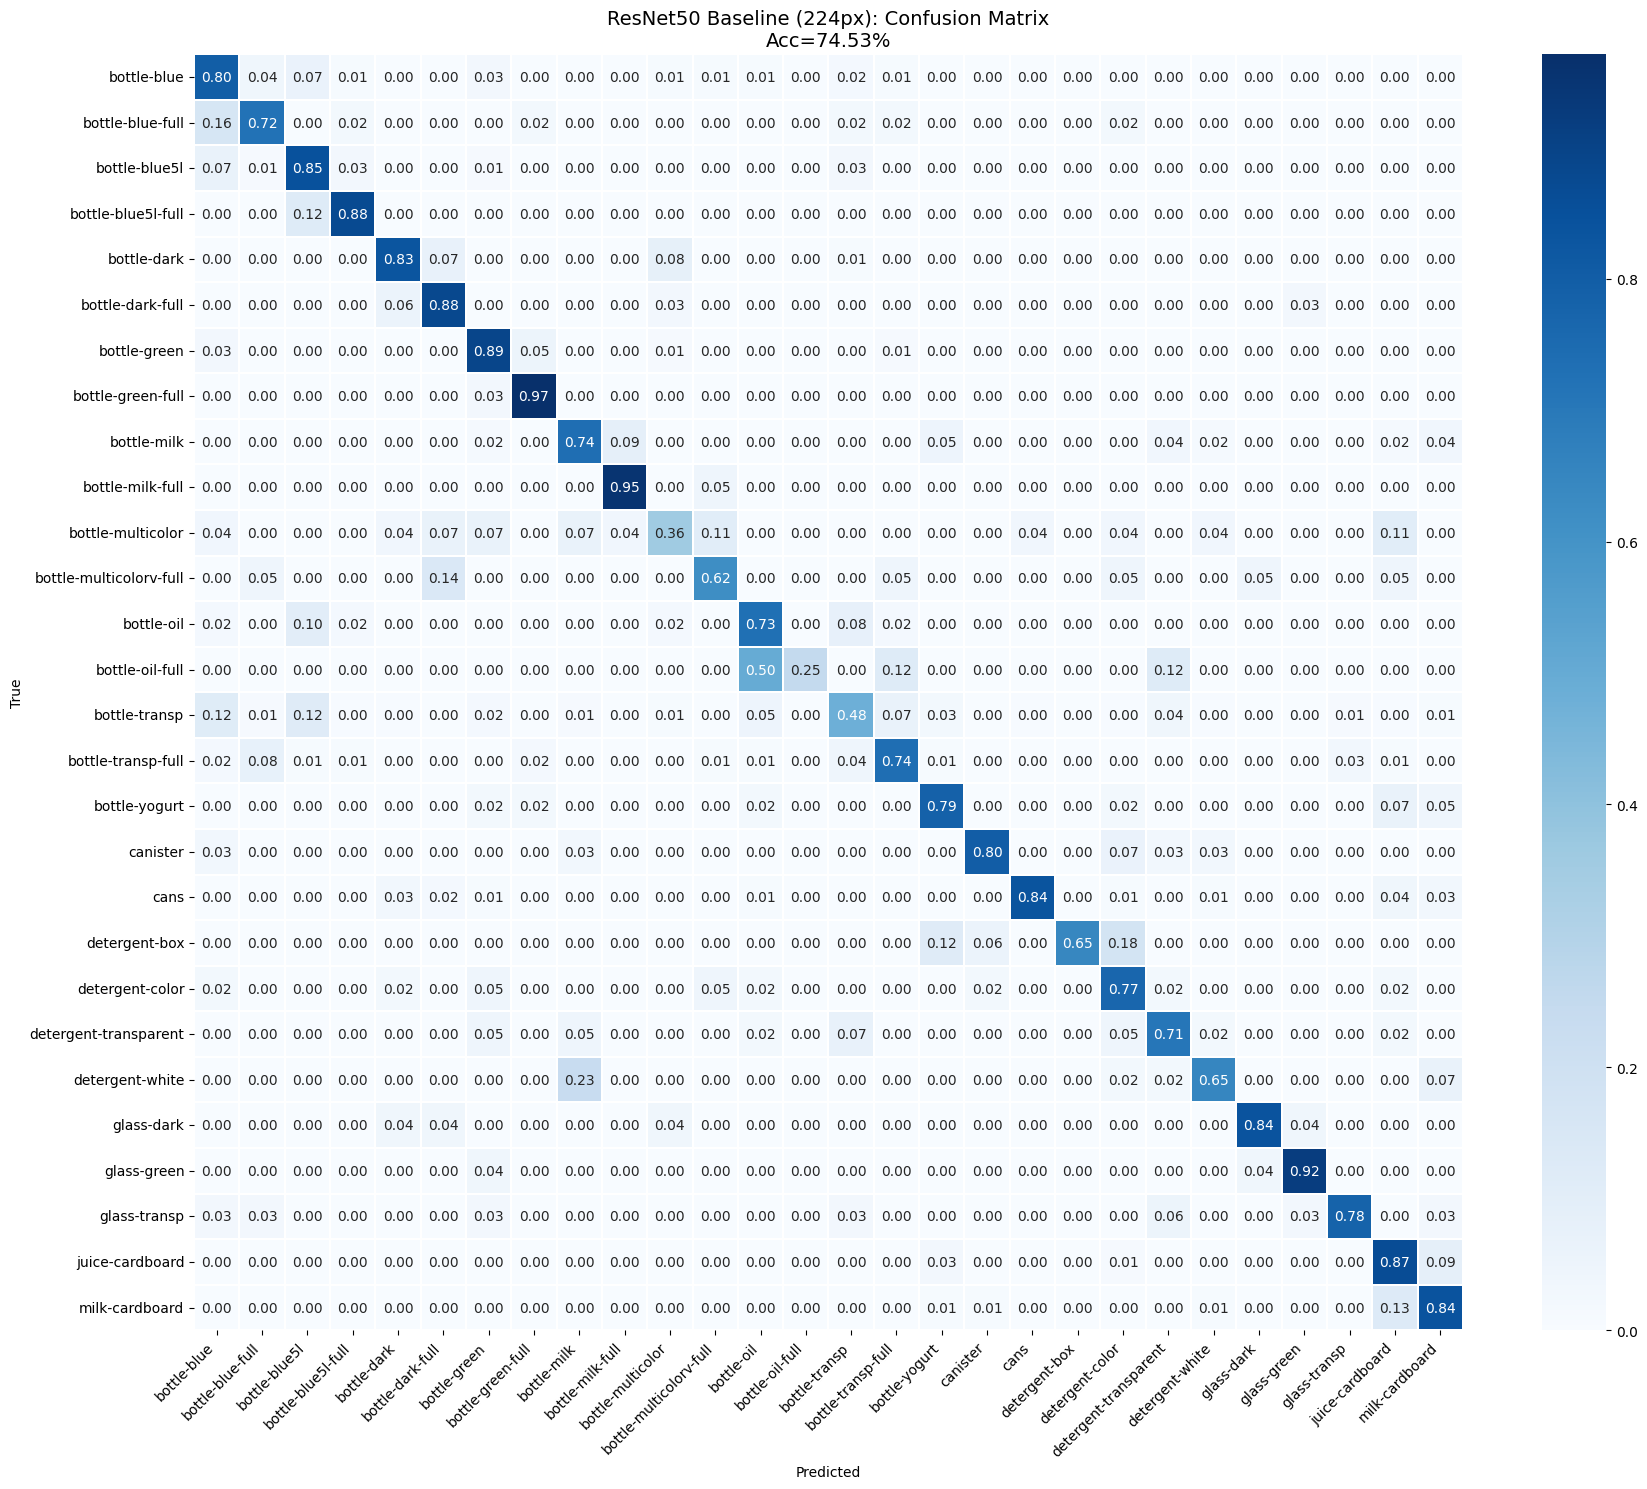

In [ ]:
# Load the best  weights 
WEIGHTS_PATH = root / "Models/weights/resnet50_baseline_224.pth"

model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=DEVICE))
model.to(DEVICE)
model.eval()

# run full-test inference
all_preds, all_labels = [], []

# inference loop for classification evaluation.
with torch.no_grad():                                   
    for imgs, lbls in test_loader:                      
        preds = model(imgs.to(DEVICE)).argmax(1).cpu()  
        all_preds.extend(preds.numpy())                 
        all_labels.extend(lbls.numpy())                 

y_pred = np.array(all_preds)    
y_true = np.array(all_labels)   

# calculate evaluation metrics
acc  = (y_pred == y_true).mean() * 100
macro_f1   = f1_score(y_true, y_pred, average="macro") * 100
weighted_f1 = f1_score(y_true, y_pred, average="weighted") * 100
prec = precision_score(y_true, y_pred, average="macro") * 100
rec  = recall_score(y_true, y_pred, average="macro") * 100

print("="*50)
print("ResNet50 Baseline (224px): Final Metrics")
print("="*50)
print(f"Accuracy     : {acc:.2f}%")
print(f"Macro F1     : {macro_f1:.2f}%")
print(f"Weighted F1  : {weighted_f1:.2f}%")
print(f"Precision    : {prec:.2f}%")
print(f"Recall       : {rec:.2f}%")
print("="*50)

# confusion matrix (normalised)
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

# plot the confusion matrix
fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.3
)
ax.set_title(f"ResNet50 Baseline (224px): Confusion Matrix\nAcc={acc:.2f}%", fontsize=14)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
